In [2]:
import matplotlib.pyplot as plt
from networkx import connected_watts_strogatz_graph
import numpy as np
import networkx as nx
import scipy
import os

from InfluenceDiffusion.Graph import Graph # class inheriting from nx.DiGraph
from InfluenceDiffusion.Trace import Trace, Traces
from InfluenceDiffusion.influence_models import ICM, LTM
from InfluenceDiffusion.estimation_models.OptimEstimation import GLTWeightEstimator
from InfluenceDiffusion.estimation_models.EMEstimation import ICWeightEstimatorEM
from InfluenceDiffusion.weight_samplers import make_random_weights_with_indeg_constraint, \
    make_random_weights_with_fixed_indeg
from InfluenceDiffusion.plot_utils import plot_with_conf_intervals, plot_hist_with_normal_fit
from InfluenceDiffusion.Inference import GLTInferenceModule
from scipy.stats.distributions import expon, beta


os.chdir("/Users/amkagan/Desktop/Archive/gltm_experiments")
from utils.utils import relative_mean_absolute_error, make_distrib_name
from utils.trace_utils import trace_train_test_split, make_report_traces
from utils.utils import random_vector_inside_simplex
from utils.graph_utils import plot_trace_subgraph


from copy import deepcopy
from functools import partial

import jax
import jax.numpy as jnp
import scipy
from tqdm import tqdm

## Generate graph and traces

In [3]:
n_nodes = 100
init_k = 5
rewire_p = 0.2
n_traces = 2000
test_ratio = 0.25

random_state = 1
max_seed_size = 10
seed_size_range = range(1, max_seed_size + 1)


g = Graph(connected_watts_strogatz_graph(n=n_nodes, k=init_k, p=rewire_p, seed=random_state))
true_weights = make_random_weights_with_indeg_constraint(g, random_state=random_state)
g.set_weights(true_weights)

true_distrib = beta(2, 1)
ltm = LTM(g, threshold_generator=true_distrib, random_state=random_state)
traces = ltm.sample_traces(n_traces=n_traces, seed_size_range=seed_size_range)

train_traces, test_traces = trace_train_test_split(traces, test_ratio=test_ratio)
test_seeds = [test_trace[0] for test_trace in test_traces]
len(train_traces), len(test_traces)

(1500, 500)

In [4]:
def extract_vertex_preactivation_masks(traces: Traces):
    g = traces[0].graph
    vertex_2_t_tm1_masks = {vertex: ([], []) for vertex in g.get_sinks()}
    vertex_2_parent_mask = {vertex: g.get_parents_mask(vertex) for vertex in g.get_sinks()}
    for trace in traces:
        for vertex in trace.get_all_failed_and_activated_vertices_no_seed():
            if vertex in trace.get_all_activated_vertices_no_seed():
                t_v = trace.get_vertex_activation_time(vertex) - 1
            else:
                t_v = trace.length
            parent_mask = vertex_2_parent_mask[vertex]
            mask_t = trace.get_active_parents_mask_at_time(vertex, time=t_v)[parent_mask]
            mask_tm1 = trace.get_active_parents_mask_at_time(vertex, time=t_v - 1)[parent_mask]
            vertex_2_t_tm1_masks[vertex][0].append(mask_t)
            vertex_2_t_tm1_masks[vertex][1].append(mask_tm1)
    return {vertex: (np.vstack(masks_t), np.vstack(masks_tm1))
            for vertex, (masks_t, masks_tm1) in vertex_2_t_tm1_masks.items() if len(masks_t) > 0}

vertex_2_preactivation_masks = extract_vertex_preactivation_masks(test_traces)

In [ ]:
all_activation_probs = []
all_pred_weights = []
all_activation_prob_conf_ints = []
all_weight_conf_ints = []


distribs = [beta(2, 1), beta(3, 1), beta(1, 1), expon()]
distrib_names = [make_distrib_name(distrib) for distrib in distribs]
init_weights = make_random_weights_with_fixed_indeg(g, indeg_ub=0.5)

for distrib in distribs:
    estimator = GLTWeightEstimator(g, vertex_2_distrib={v: distrib for v in g.get_vertices()})
    pred_weights = estimator.fit(train_traces, init_weights=init_weights).weights_
    glt_inferencer = GLTInferenceModule(estimator)
    
    vertex_2_activ_probs = {vertex: glt_inferencer.compute_vertex_conditional_activ_probs(vertex=vertex,
                                                                                          masks_t=masks_t,
                                                                                          masks_tm1=masks_tm1) 
                            for vertex, (masks_t, masks_tm1) in tqdm(vertex_2_preactivation_masks.items(), 
                                                                     position=0)}
    activation_probs = np.hstack([v for k, v in sorted(vertex_2_activ_probs.items(), 
                                                       key=lambda kv: kv[0])])
    
    
    vertex_2_conf_ints = {vertex: glt_inferencer.compute_vertex_activation_prob_conf_ints(vertex=vertex,
                                                                                          masks_t=masks_t,
                                                                                          masks_tm1=masks_tm1) 
                          for vertex, (masks_t, masks_tm1) in tqdm(vertex_2_preactivation_masks.items(), 
                                                                     position=0)}
    activation_prob_conf_ints = np.vstack([v for k, v in sorted(vertex_2_conf_ints.items(), 
                                                                key=lambda kv: kv[0])])
    
    
    all_pred_weights.append(pred_weights)
    all_weight_conf_ints.append(glt_inferencer.compute_all_weight_conf_ints())
    all_activation_probs.append(activation_probs)
    all_activation_prob_conf_ints.append(activation_prob_conf_ints)

In [ ]:
oracle_estimator = GLTWeightEstimator(g, vertex_2_distrib={v: true_distrib for v in g.get_vertices()})
oracle_estimator._pre_fit(train_traces, init_weights=true_weights)
oracle_glt_inferencer =  GLTInferenceModule(oracle_estimator)

vertex_2_true_activ_prob = {vertex: oracle_glt_inferencer.compute_vertex_conditional_activ_probs(
                                        vertex=vertex, masks_t=masks_t, masks_tm1=masks_tm1) 
                            for vertex, (masks_t, masks_tm1) in tqdm(vertex_2_preactivation_masks.items(),
                                                                     position=0)}
true_activation_probs = np.hstack([v for k, v in sorted(vertex_2_true_activ_prob.items(), 
                                                        key=lambda kv: kv[0])], dtype=float)

In [ ]:
all_spred_conf_ints = np.stack(all_spred_conf_ints)

In [ ]:
true_test_spread = np.array([len(trace.get_all_activated_vertices()) for trace in test_traces])

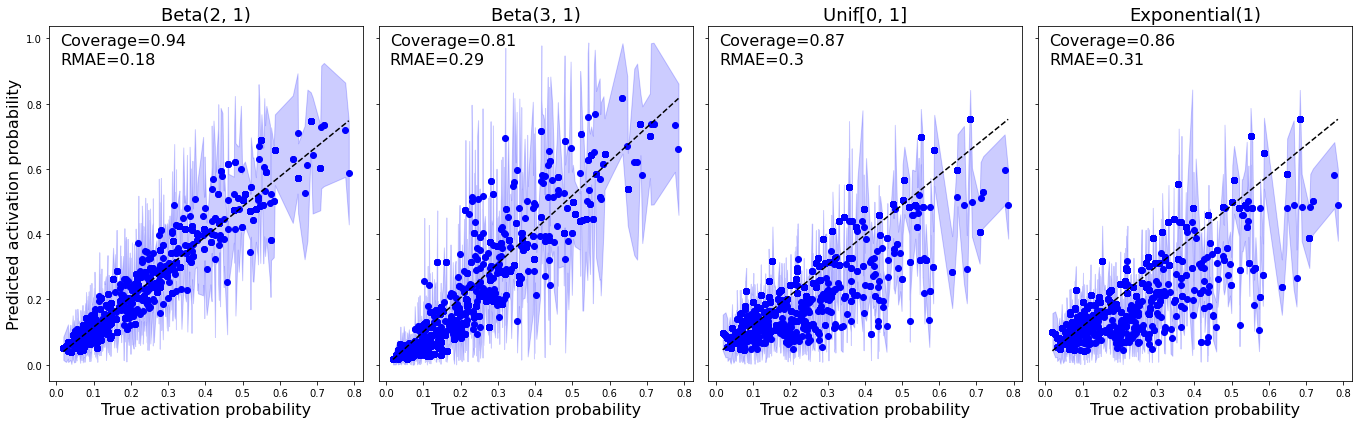

In [51]:
fig, axs = plt.subplots(1, len(distribs), figsize=(19, 6), sharex=True, sharey=True)

# rare confidence intervals for nodes with little propagation data available behave unstable and blow up
mask = ((np.stack(all_activation_prob_conf_ints)[:, :, 0] > 1e-6) & \
        (np.stack(all_activation_prob_conf_ints)[:, :, 1] < 0.99)).all(0)

fontsize=16

for i, (ax, distrib, activation_probs, conf_ints) in enumerate(zip(axs, 
                                                                   distribs, 
                                                                   all_activation_probs, 
                                                                   all_activation_prob_conf_ints)):
    
    rmae = np.round(relative_mean_absolute_error(true_activation_probs, activation_probs), 2)
    avg_conf_int_length = np.nanmean(conf_ints[:, 1] - conf_ints[:, 0]).round(2)
    std_conf_int_length = np.nanstd(conf_ints[:, 1] - conf_ints[:, 0]).round(2)
    
    coverage = np.mean((true_activation_probs >= conf_ints[:, 0]) &
                       (true_activation_probs <= conf_ints[:, 1])).round(2)
    
    ylab = "Predicted activation probability" if i == 0 else None
#     ax.text(0.01, 0.98, f"Average CI length={avg_conf_int_length}", 
#             fontsize=fontsize)
    ax.text(0.01, 0.98, f"Coverage={coverage}", fontsize=fontsize)
    ax.text(0.01, 0.92, f"RMAE={rmae}", fontsize=fontsize)
 
    
    plot_with_conf_intervals(true_activation_probs[mask], activation_probs[mask], 
                             conf_intervals=conf_ints[mask].T, 
                             ylab=ylab, ax=ax, fontsize=fontsize, color="blue")
    ax.set_title(make_distrib_name(distrib), fontsize=fontsize + 2)
fig.tight_layout(w_pad=1.075)   
plt.savefig('figures/transition_prob_estimation.png', dpi=200)

In [240]:
all_activ_prob_conf_ints = []

for distrib in distribs:
    estimator = GLTWeightEstimator(g, vertex_2_distrib={v: distrib for v in g.get_vertices()})
    pred_weights = estimator.fit(train_traces, init_weights=init_weights).weights_
    glt_inferencer = GLTInferenceModule(estimator)
    vertex_2_conf_ints = {vertex: glt_inferencer.compute_vertex_activation_prob_conf_ints(vertex=vertex,
                                                                                            masks_t=masks_t,
                                                                                            masks_tm1=masks_tm1) 
                            for vertex, (masks_t, masks_tm1) in tqdm(vertex_2_preactivation_masks.items(), 
                                                                     position=0)}
    all_activ_prob_conf_ints.append(np.vstack([v for k, v in sorted(vertex_2_conf_ints.items(), 
                                             key=lambda kv: kv[0])], dtype=float))

100%|████████████| 100/100 [01:41<00:00,  1.01s/it]


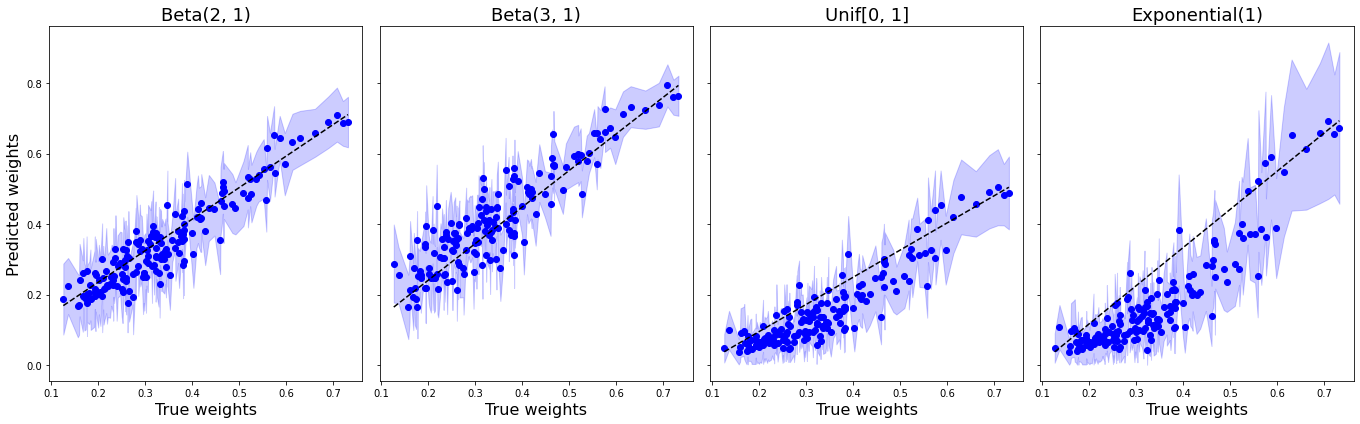

In [16]:
fig, axs = plt.subplots(1, len(distribs), figsize=(19, 6), sharex=True, sharey=True)

# rare confidence intervals for nodes with little propagation data available behave unstable and blow up
mask = ((np.stack(all_weight_conf_ints)[:, :, 0] > 1e-6) & \
        (np.stack(all_weight_conf_ints)[:, :, 1] < 0.99)).all(0)
fontsize=16

for i, (ax, distrib, pred_weights, conf_ints) in enumerate(zip(axs, 
                                                                   distribs, 
                                                                   all_pred_weights, 
                                                                   all_weight_conf_ints)):
    ylab = "Predicted weights" if i == 0 else None
    xlab = "True weights"
    plot_with_conf_intervals(true_weights[mask], pred_weights[mask], conf_intervals=conf_ints[mask].T, 
                             ylab=ylab, xlab=xlab, ax=ax, fontsize=fontsize, color="blue")
    ax.set_title(make_distrib_name(distrib), fontsize=fontsize + 2)
fig.tight_layout(w_pad=1.075)   
plt.savefig('figures/weight_estimation.png', dpi=200)

In [40]:
all_test_nlls = {}

for distrib_name, distrib in zip(distrib_names, distribs):
    estimator = GLTWeightEstimator(g, vertex_2_distrib={v: distrib for v in g.get_vertices()})
    pred_weights = estimator.fit(train_traces, init_weights=init_weights).weights_
    estimator._pre_fit(traces=test_traces)
    all_test_nlls[distrib_name] = estimator._compute_total_nll(pred_weights)
    
oracle_estimator._pre_fit(traces=test_traces, init_weights=true_weights)
all_test_nlls["Groundtruth"] = oracle_estimator._compute_total_nll(true_weights)
all_test_nlls

{'Beta(2, 1)': 2547.901527250235,
 'Beta(3, 1)': 2758.6895007236235,
 'Unif[0, 1]': 2770.023521233767,
 'Exponential(1)': 2794.674881851636,
 'Groundtruth': 2426.4766614451723}

## Individual weight conf ints

In [11]:
def make_jax_cdf(distrib: scipy.stats._distn_infrastructure.rv_frozen):
    name = distrib.dist.name
    args = distrib.args
    kwargs = distrib.kwds
    local_dic = {}
    exec(f"jax_distrib=jax.scipy.stats.{name}", None, local_dic)
    jax_distrib = local_dic["jax_distrib"]
    if name == "expon":
        return lambda x: 1. - jnp.exp(-x)
    return lambda x: jax_distrib.cdf(x, *args, **kwargs)

def make_all_subset_masks(n, include_empty=True):
    from itertools import product
    masks = list(product([0, 1], repeat=n))
    if not include_empty:
        masks = masks[1:]
    return np.array(masks, dtype=bool)

In [12]:
def make_one_child_node_graph_and_traces(n_edges, n_traces, distrib, 
                                         init_weights=None, fixed_indeg=False, indeg_ub=1., 
                                         random_seed=None):
    np.random.seed(random_seed)
    parent_nodes = np.arange(1, n_edges + 1) 
    g = Graph([[i, 0] for i in parent_nodes])
    if init_weights is None:
        if fixed_indeg:
            weights = make_random_weights_with_fixed_indeg(g, indeg_ub=indeg_ub)
        else:
            weights = make_random_weights_with_indeg_constraint(g, indeg_ub=indeg_ub)
        weights = np.sort(weights)
    else:
        weights = init_weights
    g.set_weights(weights)
    diff_model = LTM(g, threshold_generator=distrib)

    # P_0 is Uniform on all subsets 
    seed_masks = make_all_subset_masks(n_edges, include_empty=False)
    seed_set_indices = np.random.choice(np.arange(len(seed_masks)), size=n_traces, replace=True)
    seed_sets = [set(parent_nodes[seed_masks[i]]) for i in seed_set_indices]
    traces = [diff_model.sample_trace(seed_set=seed_set) for seed_set in seed_sets]
    return g, traces   

In [32]:
def compute_oracle_hessian_one_child_node_graph(true_weights: np.array, 
                                                true_distrib: scipy.stats._distn_infrastructure.rv_frozen,
                                                seed_mask_2_prob: dict[tuple[bool], float] = None):
    
    cdf = glt_inferencer._make_jax_cdf(true_distrib)
    true_weights = jnp.array(true_weights, dtype=jnp.float32)
    n_edges = len(true_weights)
    masks = jnp.array(make_all_subset_masks(n_edges, include_empty=False), dtype=float)

    if seed_mask_2_prob:
        seed_probs = jnp.array([seed_mask_2_prob[tuple(mask)] for mask in masks])
    else:
        seed_probs = jnp.ones(2 ** n_edges  - 1) / (2 ** n_edges - 1)
        
    activ_probs = cdf(masks @ true_weights)
    fail_probs = 1. - activ_probs
    activ_trace_probs = activ_probs * seed_probs
    fail_trace_probs = fail_probs * seed_probs
    activ_hessians =  jnp.array([jax.hessian(lambda x: jnp.log(cdf(x)))(prob) for prob in activ_probs])
    fail_hessians = jnp.array([jax.hessian(lambda x: jnp.log(1. - cdf(x)))(prob) for prob in activ_probs])
    return masks.T @ np.diag(activ_hessians * activ_trace_probs + fail_hessians * fail_trace_probs) @ masks 


## Inference for individual edges

In [48]:
n_simulations = 1000
n_edges = 3
n_traces = 500
true_distrib = beta(1, 1)

In [49]:
all_conf_ints = []
all_pred_weights = []
n_interval_hits = np.zeros(n_edges)
true_weights_one_node = np.array([0.15, 0.3, 0.55])

for _ in tqdm(range(n_simulations)):
    g, traces = make_one_child_node_graph_and_traces(n_edges=n_edges, n_traces=n_traces, 
                                                     distrib=true_distrib, init_weights=true_weights_one_node)
    estimator = GLTWeightEstimator(g, vertex_2_distrib=true_distrib)
    pred_weights = estimator.fit(traces).weights_
    glt_inferencer = GLTInferenceModule(estimator)
    conf_ints = glt_inferencer.compute_all_weight_conf_ints()
    
    all_conf_ints.append(conf_ints)
    all_pred_weights.append(pred_weights)
    n_interval_hits += (true_weights_one_node >= conf_ints[:, 0]) & (true_weights_one_node <= conf_ints[:, 1])

print(n_interval_hits / n_simulations)

100%|██████████████████████████████████████████████████████████| 1000/1000 [00:52<00:00, 19.12it/s]

[0.967 0.957 0.962]


In [50]:
true_asympt_fisher = -compute_oracle_hessian_one_child_node_graph(true_weights_one_node, true_distrib=true_distrib)
true_asympt_stds = np.sqrt(np.diag(np.linalg.inv(true_asympt_fisher)))

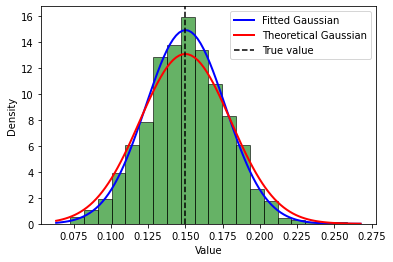

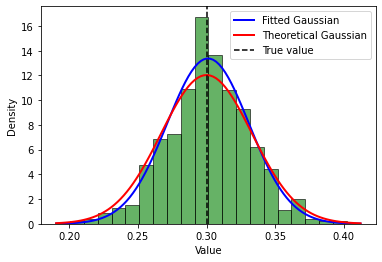

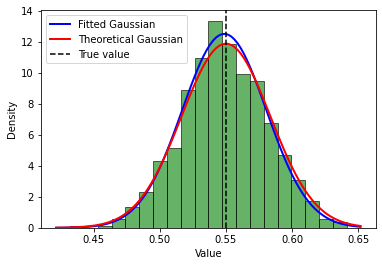

In [51]:
for i in np.argsort(true_weights_one_node):
    plot_hist_with_normal_fit(sample=np.vstack(all_pred_weights)[:, i], true_value=true_weights_one_node[i], 
                              true_std=true_asympt_stds[i] / np.sqrt(n_traces),
                              n_bins=20)
    plt.show()